In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import joypy
from matplotlib import cm

In [ ]:
from numpy import pad


def histogram_mean(histogram):
        total_sum = 0
        total_count = 0
        for value, frequency in enumerate(histogram):
            total_sum += value * frequency
            total_count += frequency
        return total_sum / total_count


# Assuming you have a numpy array 'histograms' with shape (n, m)
# where n is the number of histograms and m is the length of each histogram
# For example:
# histograms = np.random.rand(10, 100)  # 10 histograms of length 100 each

def create_ridge_plot_from_histograms(histograms, bin_edges=None, row_labels=None, title="", 
                                     x_labels=None, x_label_positions=None, x_axis_label="", vlines=None):
    """
    Create a ridge plot from a numpy array of histograms.
    
    Parameters:
    - histograms: numpy array of shape (n, m) where n is the number of histograms and m is the length of each
    - bin_edges: numpy array of bin edges (length m+1) or None to use indices
    - row_labels: list of labels for each histogram or None to use indices
    - title: title for the plot
    - x_labels: custom labels for x-axis
    - x_label_positions: positions for the custom x-axis labels
    - x_axis_label: label for the x-axis
    """
    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
    n, m = histograms.shape
    
    if bin_edges is None:
        # If no bin edges provided, use array indices as x-coordinates
        bin_centers = np.arange(m)
    else:
        # If bin edges provided, use bin centers as x-coordinatesw
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if row_labels is None:
        # If no labels provided, use indices as labels
        row_labels = [f"Histogram {i}" for i in range(n)]
    
    # Create a DataFrame with all histogram values in long form
    data = []
    histograms = histograms * np.max(histograms) * 10000  # Scale to manageable numbers
    for i in range(n):
        for j in range(m):
            density = histograms[i, j]
            for _ in range(density.astype(int)):
                data.append({
                    'y': j,
                    'group': row_labels[i]
                })
    
    df = pd.DataFrame(data)
    df = df.sort_values('group', ascending=True)
    df = df.groupby('group', sort=False)
    
    fig, axes = joypy.joyplot(df,
                             by='group',
                             column='y',
                             grid=False,
                             linewidth=1,
                             legend=False,
                             figsize=(6,5),
                             title=title,
                             colormap=cm.autumn_r,
                             ylabels=False,
                            #  range_style='all',
                            range_style=[0,218],
                             kind="counts")
    
    # Get the bottom-most axis (the one that has the x-axis labels)
    bottom_ax = axes[-1]
    
    # Set xlim if needed
    # plt.xlim(left=0, right=218)
    
    # Apply custom x-axis labels if provided
    if x_labels is not None and x_label_positions is not None:
        bottom_ax.set_xticks(x_label_positions)
        bottom_ax.set_xticklabels(x_labels, rotation=-45, ha='left')
        bottom_ax.tick_params(axis='x', labelsize=6, pad=0) 
        bottom_ax.vlines(x=vlines, ymin=0, ymax=1, transform=bottom_ax.get_xaxis_transform(), colors='gray', linestyles='--', alpha=0.7)
        
    # Set x and y axis labels
    plt.xlabel(x_axis_label if x_axis_label else "Microstates (1 Nuc -> 216 FG Nups -> 1 Cyt)")
    plt.ylabel("Cluster")
    
    return fig, axes

# Example usage:
# histograms = np.random.rand(10, 100)  # Replace with your actual histogram data
# bin_edges = np.linspace(0, 10, 101)  # Replace with your actual bin edges
# labels = [f"Category {chr(65+i)}" for i in range(10)]  # Replace with your actual labels
# 
# g = create_ridge_plot_from_histograms(histograms, bin_edges, labels)
# plt.savefig("ridge_plot.png", dpi=300, bbox_inches="tight")
# plt.show()

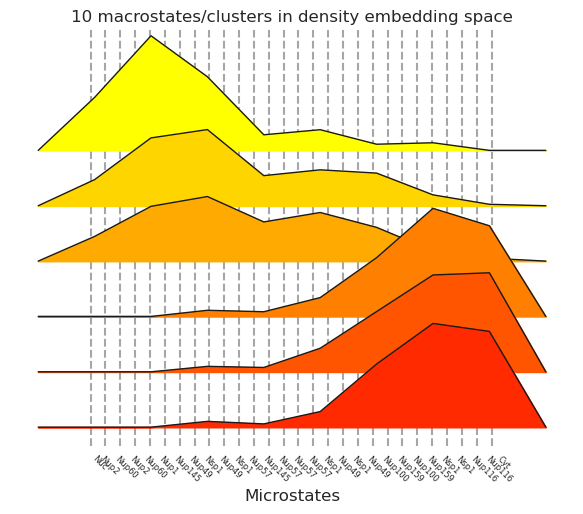

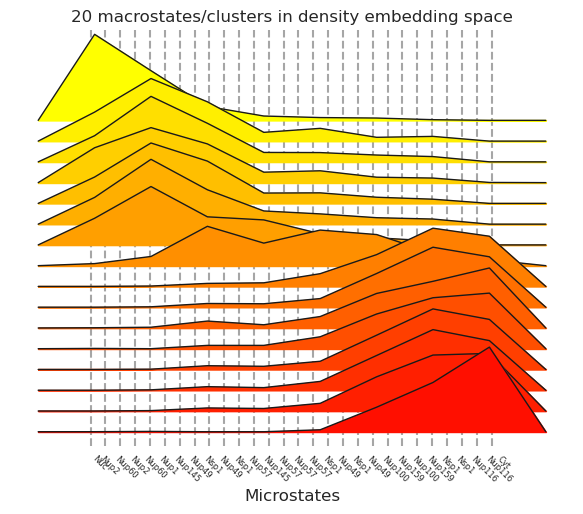

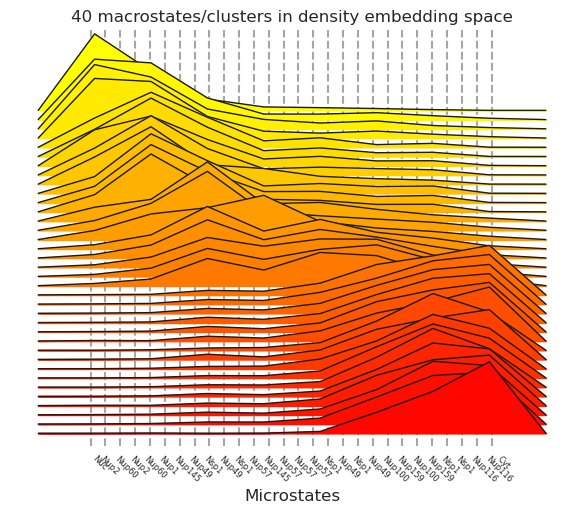

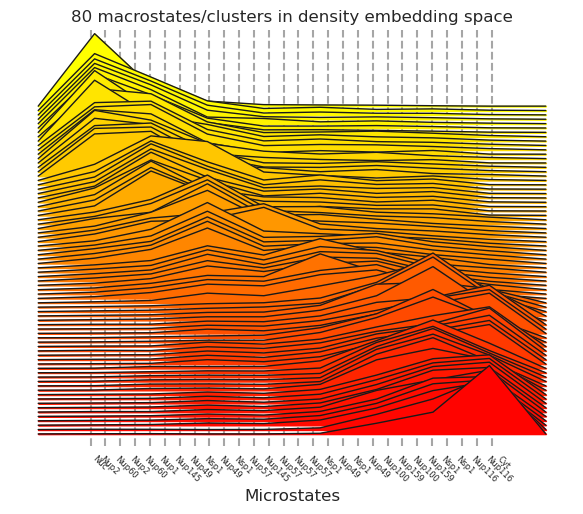

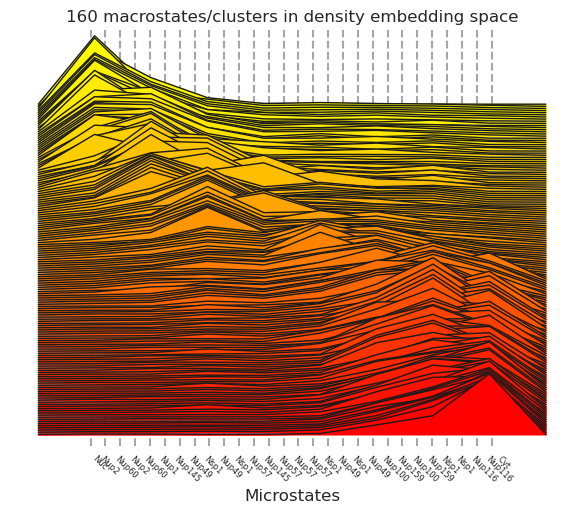

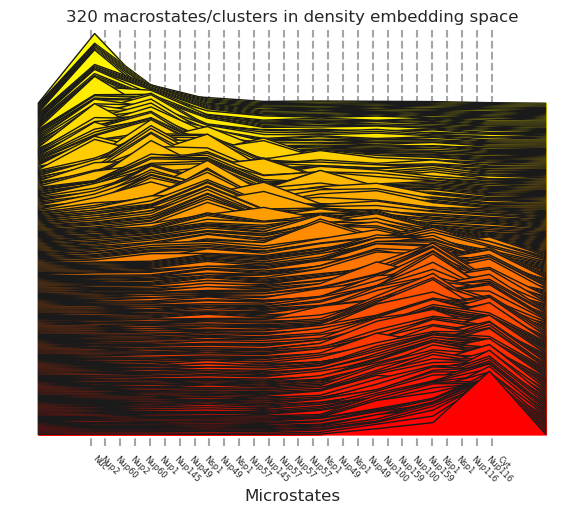

In [59]:
for n_clusters in [10, 20, 40, 80, 160, 320]:
    with open(f"data/clusterings/interactions-150-180-100ns-3k-hist-74pca-kmeans-{n_clusters}clusters.pickle", "rb") as f:
            pca_cluster = pickle.load(f)
    centers = pca_cluster.get_inverse_centers_normalized()
    
    # remove first and last (too big)
    centers = centers[2:-2]
    
    # sort clusters by center
    hist_means = np.zeros(centers.shape[0])
    for i in range(centers.shape[0]):
        hist_means[i] = histogram_mean(centers[i])
    sorted_indices = np.argsort(hist_means)
    sorted_centers = centers[sorted_indices]
    # sorted_centers[sorted_centers < 0.04] = 0
    
    
    custom_labels = ["Nuc", "Nup2", "Nup60", "Nup2", "Nup60", "Nup1", "Nup145", 
                "Nup49", "Nsp1", "Nup49", "Nsp1", "Nup57", "Nup145", 
                "Nup57", "Nup57", "Nup57", "Nsp1", "Nup49", "Nsp1", 
                "Nup49", "Nup100", "Nup159", "Nup100", "Nup159", 
                "Nsp1", "Nsp1", "Nup116", "Nup116", "Cyt"]
    custom_positions = [0] + [i*8 - 4 for i in range(1, len(custom_labels) - 1)] + [218]
    vlines = [i*8 for i in range(len(custom_labels)-1)]
    create_ridge_plot_from_histograms(sorted_centers,
                                      row_labels=[i for i in range(centers.shape[0])],
                                      title=f"{n_clusters} macrostates/clusters in density embedding space",
                                      x_labels=custom_labels,
                                      x_label_positions=custom_positions,
                                      x_axis_label="Microstates",
                                      vlines=vlines)


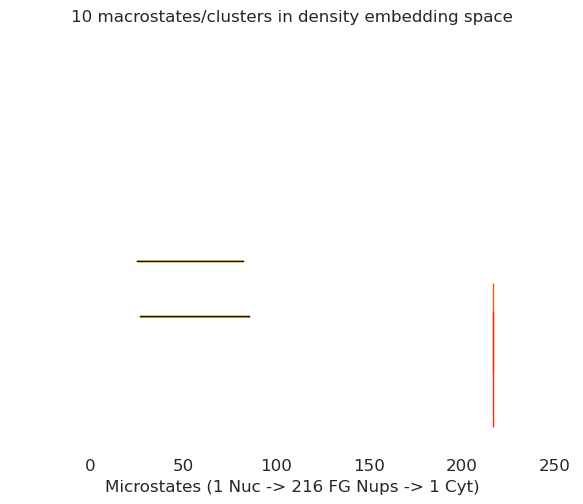

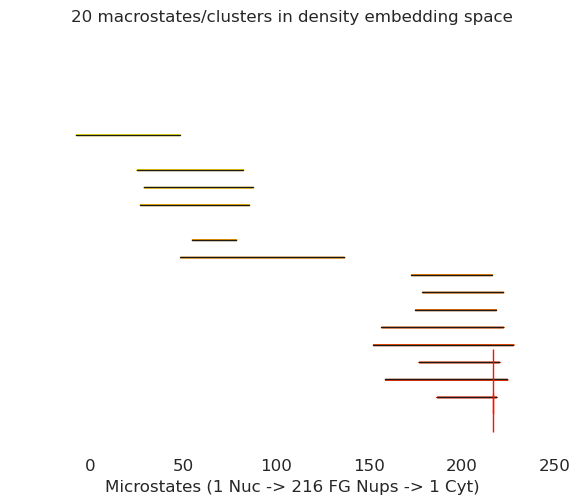

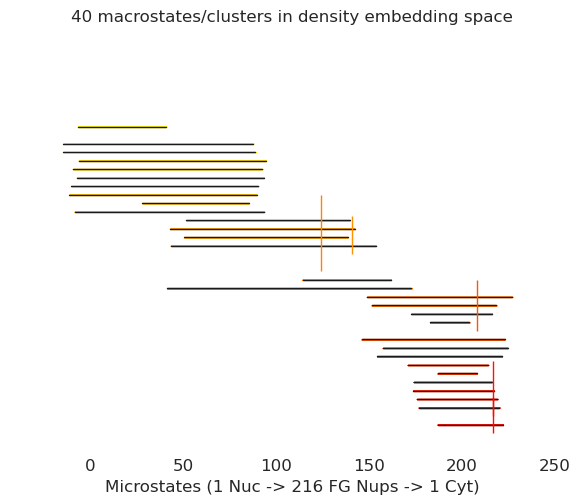

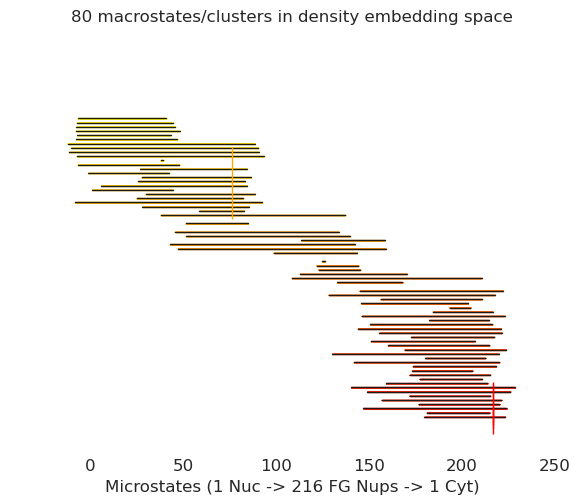

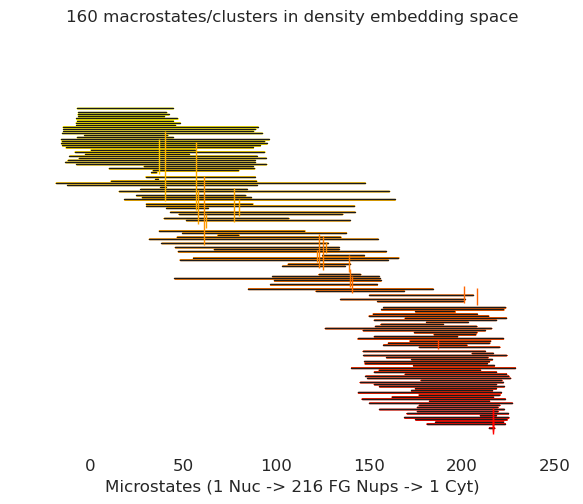

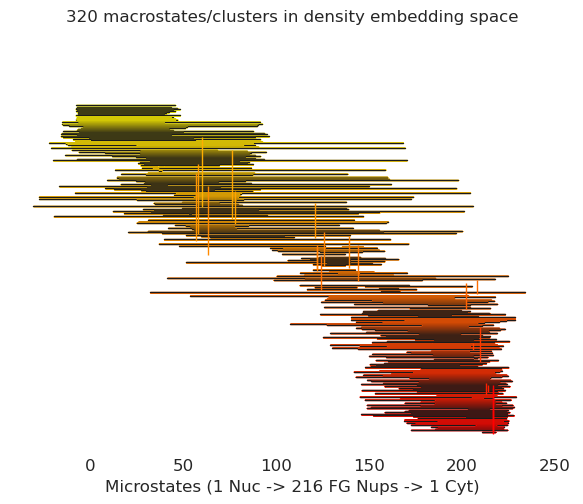

In [4]:
for n_clusters in [10, 20, 40, 80, 160, 320]:
    with open(f"data/clusterings/interactions-150-180-100ns-3k-hist-bisectingkmeans-{n_clusters}clusters.pickle", "rb") as f:
            clustering = pickle.load(f)
    centers = clustering.cluster_centers_
    # sort clusters by center of mass

    hist_means = np.zeros(centers.shape[0])
    for i in range(centers.shape[0]):
        hist_means[i] = histogram_mean(centers[i])
    sorted_indices = np.argsort(hist_means)
    sorted_centers = centers[sorted_indices]
    sorted_centers[sorted_centers < 0.04] = 0
    create_ridge_plot_from_histograms(sorted_centers,
                                      row_labels=[i for i in range(centers.shape[0])],
                                      title=f"{n_clusters} macrostates/clusters in density embedding space")
